In [3]:
import pandas as pd

df = pd.read_csv('../results/Hyperparams.csv')
display(df)

,Name,State,beta,alpha,version,after_test_recall@20,after_test_ndcg@20,unlearn_positive_rank_drop_ratio,unlearn_positive_rank_change,unlearn_positive_avg_rank_unlearned,retraining_recall@100,retraining_ndcg@100,dataset,script_name,attack,gcn_layers,Runtime
0,amber-vortex-3117,finished,25,0.4,v7,0.059621,0.046581,0.809045,-13.892239,74.901731,0.910957,0.934010,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1419
1,faithful-dew-3104,finished,30,0.3,v7,0.059596,0.046552,0.812395,-13.850921,74.860413,0.910946,0.934006,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1407
2,laced-surf-3120,finished,30,0.4,v7,0.059623,0.046578,0.845338,-15.763819,76.773311,0.910948,0.934006,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1427
3,sparkling-valley-3114,finished,20,0.4,v7,0.059630,0.046589,0.771636,-12.052485,73.061977,0.910951,0.934004,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1389
4,deep-yogurt-3101,finished,25,0.3,v7,0.059595,0.046550,0.783920,-12.245673,73.255165,0.910942,0.934002,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1425
5,hardy-glade-3106,finished,35,0.3,v7,0.059596,0.046547,0.844779,-15.515913,76.525405,0.910939,0.934002,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1404
6,daily-morning-3123,finished,35,0.4,v7,0.059618,0.046575,0.870463,-17.599107,78.608599,0.910939,0.933999,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1459
7,vocal-sponge-3109,finished,40,0.3,v7,0.059590,0.046546,0.865997,-17.083752,78.093244,0.910927,0.933994,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1459
8,smart-silence-3098,finished,20,0.3,v7,0.059603,0.046564,0.740369,-10.610832,71.620324,0.910932,0.933993,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1390
9,copper-sponge-3083,finished,35,0.2,v7,0.059601,0.046533,0.818537,-13.819095,74.828587,0.910915,0.933985,Amazon_Book,jointsvd_lightgcn_Amazon_Book.py,0.001,1,1408


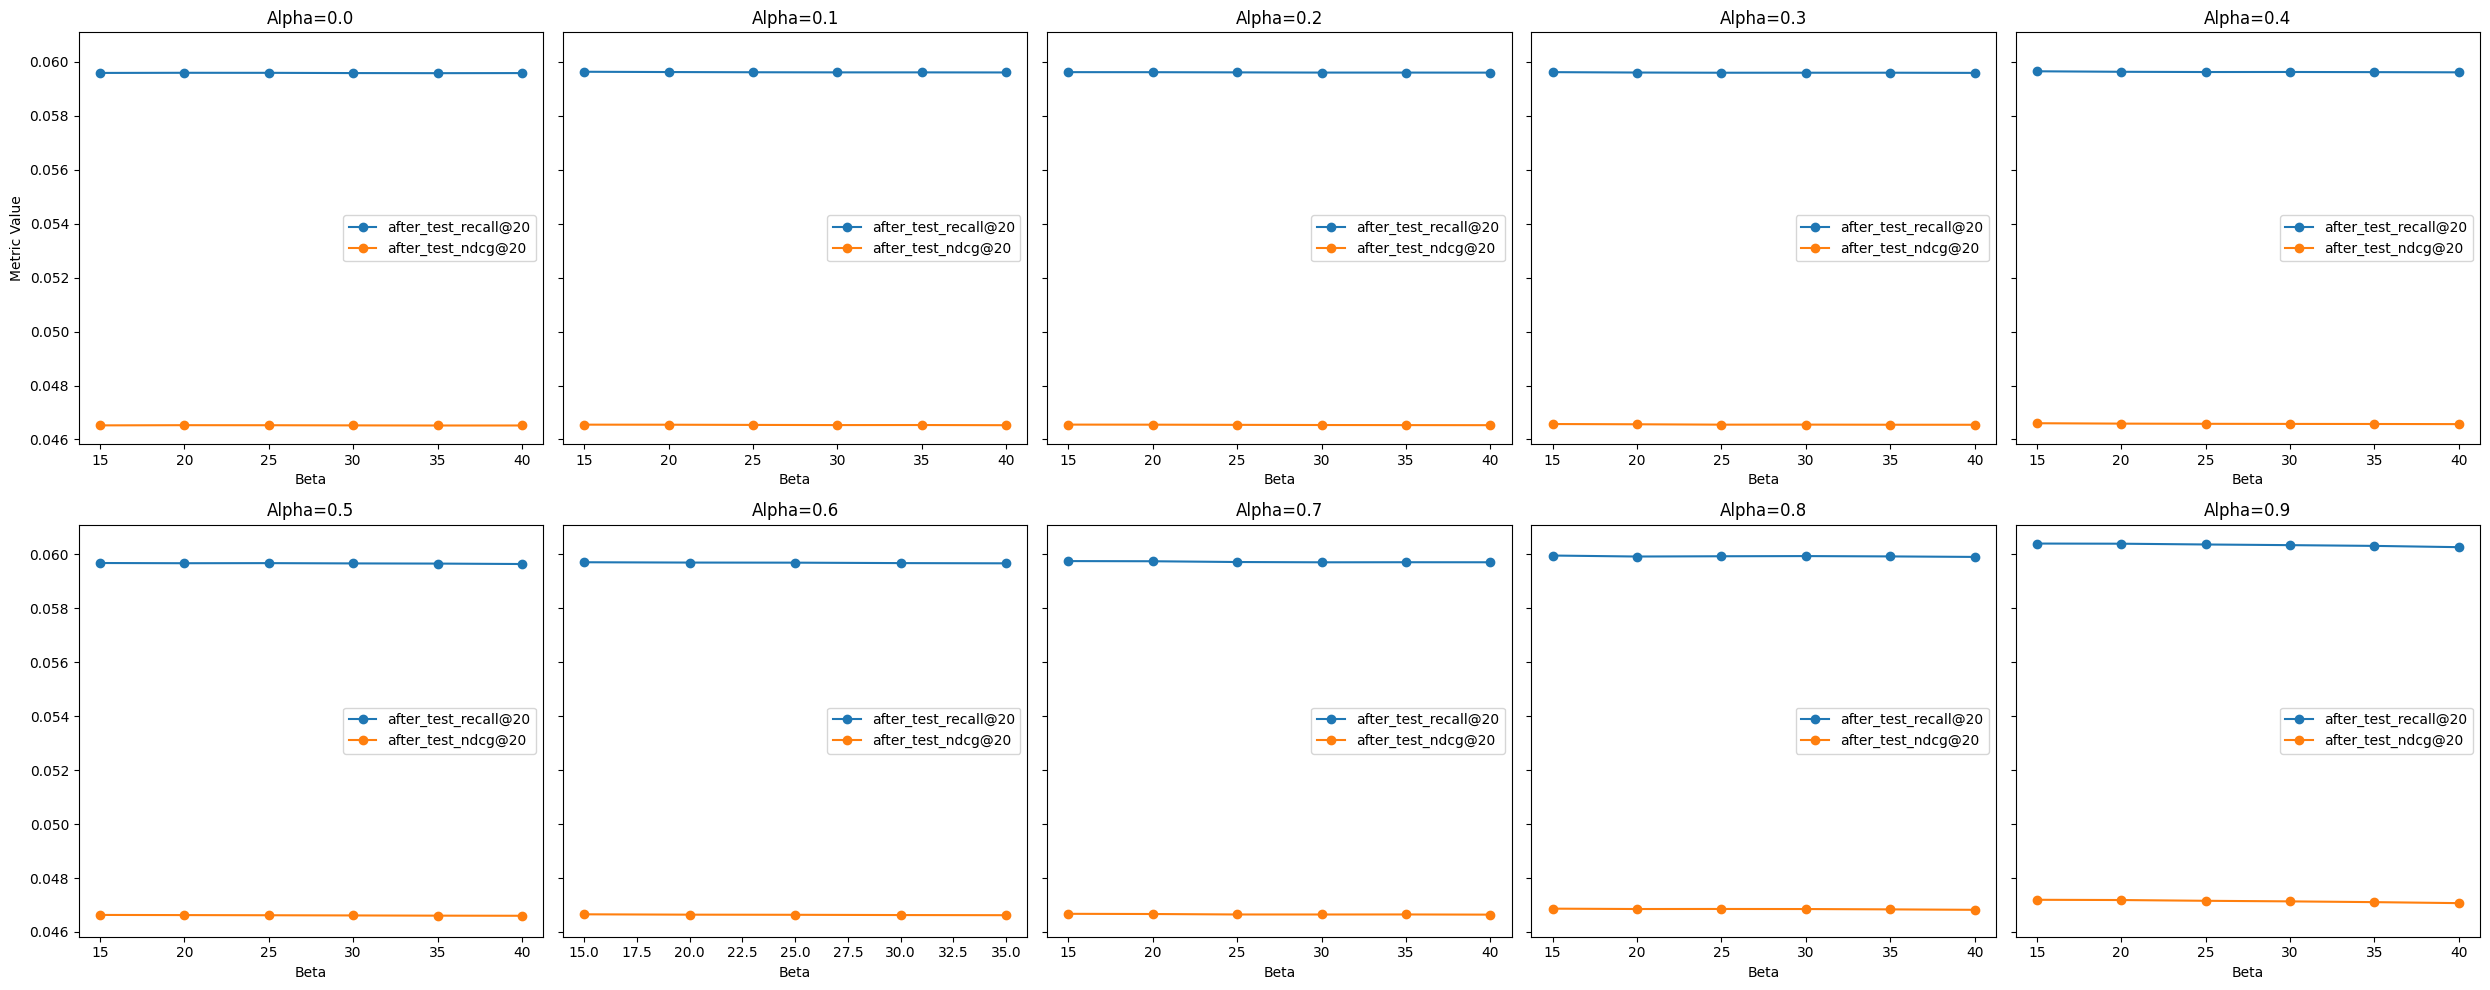

In [11]:
# alpha별로 beta 변화에 따른 recall, ndcg 시각화 (x축: beta, y축: metric)
import matplotlib.pyplot as plt
metrics = ['after_test_recall@20', 'after_test_ndcg@20']  # 필요한 열 이름으로 수정
unique_alphas = sorted(df['alpha'].unique())
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharey=True)
axes = axes.flatten()
for idx, alpha in enumerate(unique_alphas):
    subset = df[df['alpha'] == alpha]
    if 'beta' in subset.columns:
        unique_betas = sorted(subset['beta'].unique())
        for metric in metrics:
            axes[idx].plot(unique_betas, [subset[subset['beta']==b][metric].mean() for b in unique_betas], marker='o', label=metric)
        axes[idx].set_title(f'Alpha={alpha}')
        axes[idx].set_xlabel('Beta')
        axes[idx].legend()
axes[0].set_ylabel('Metric Value')
plt.tight_layout()
plt.show()

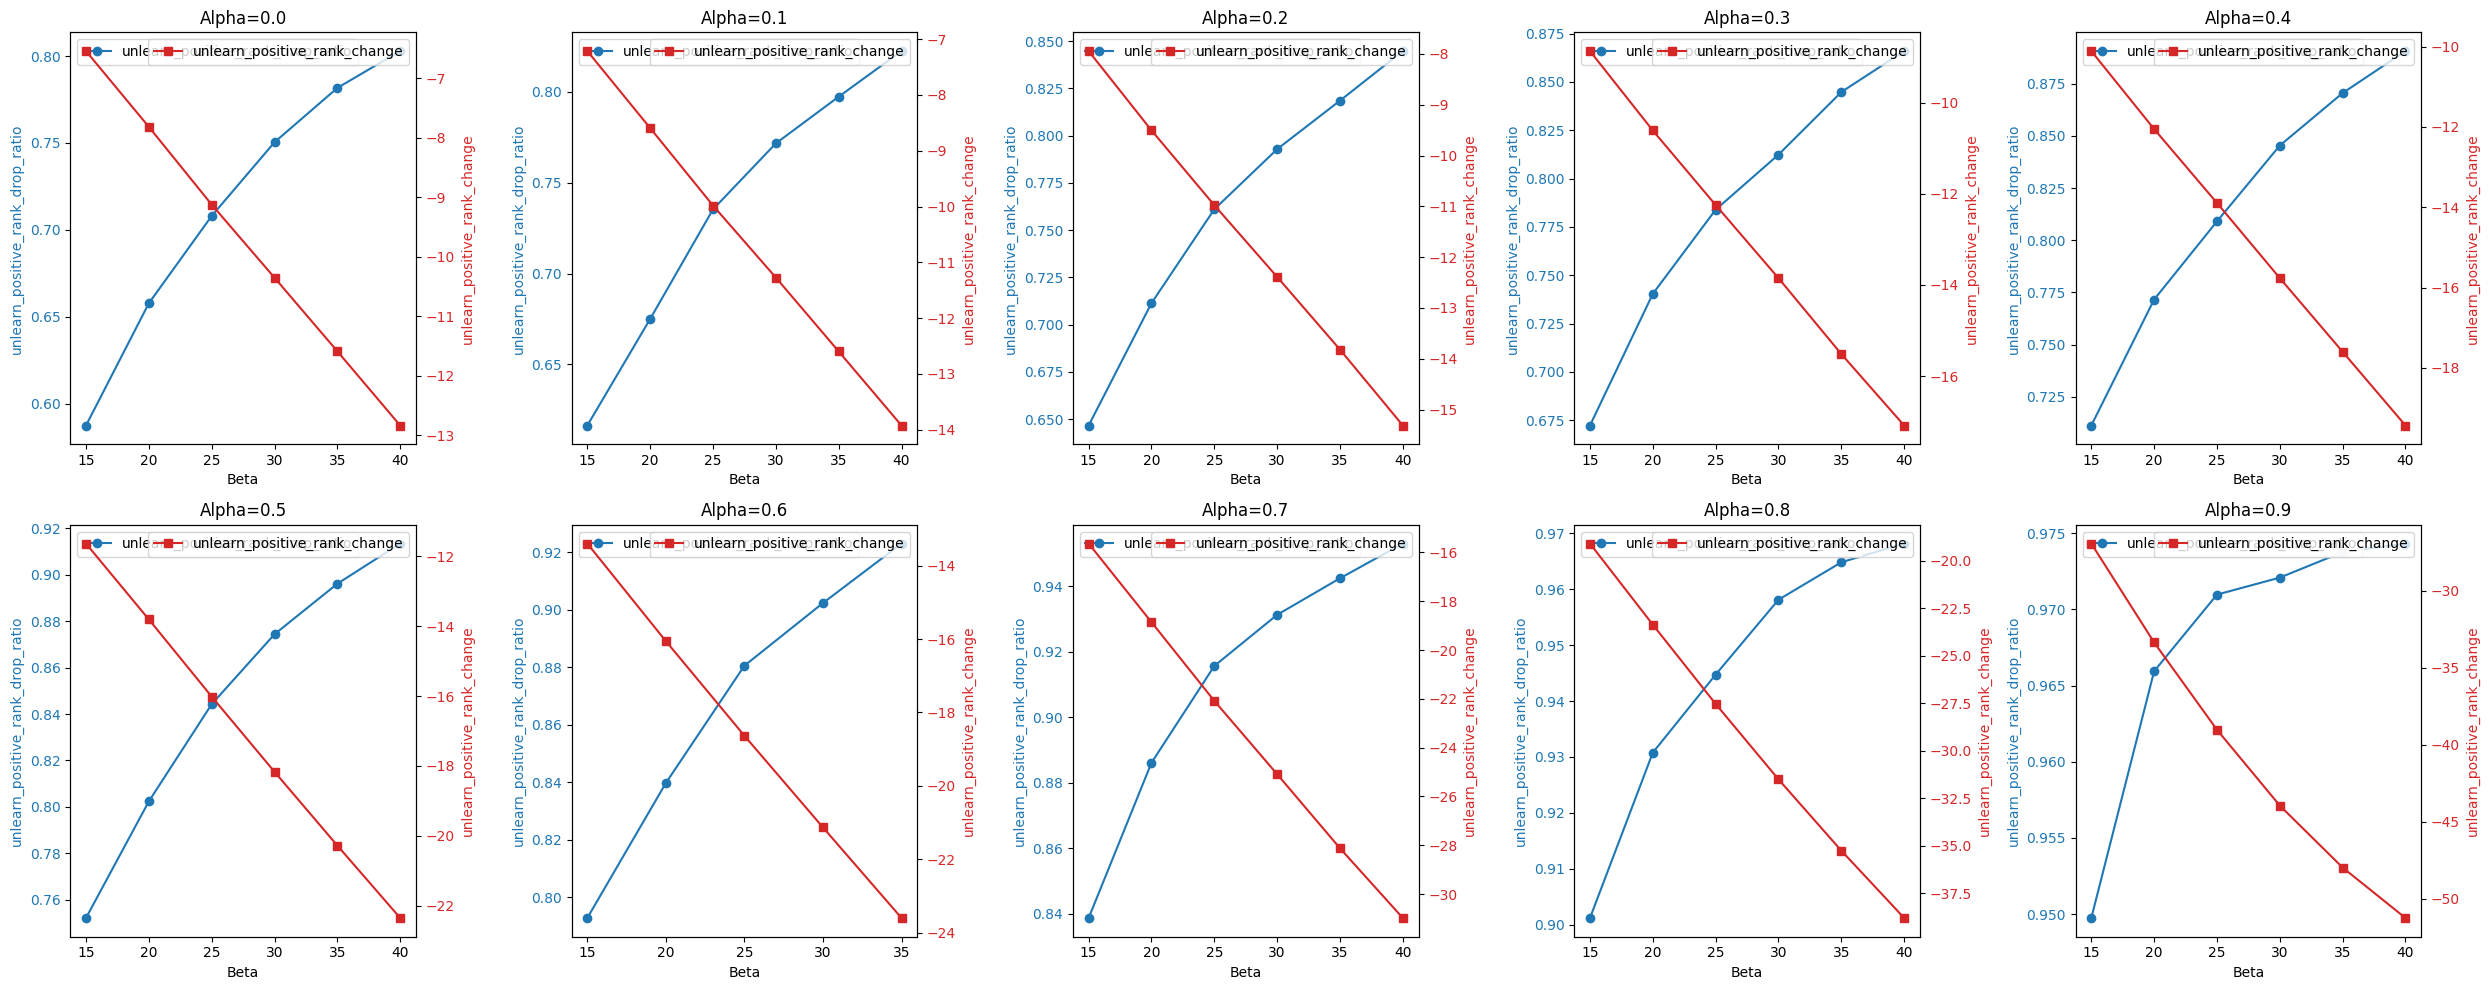

In [13]:
# alpha별로 beta 변화에 따른 두 metric을 좌우 y축으로 비교 시각화
import matplotlib.pyplot as plt
metrics = ['unlearn_positive_rank_drop_ratio', 'unlearn_positive_rank_change']  # 필요한 열 이름으로 수정
unique_alphas = sorted(df['alpha'].unique())
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharey=False)
axes = axes.flatten()
for idx, alpha in enumerate(unique_alphas):
    subset = df[df['alpha'] == alpha]
    if 'beta' in subset.columns:
        unique_betas = sorted(subset['beta'].unique())
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        # 왼쪽 y축: drop ratio (0~1)
        ax1.plot(unique_betas, [subset[subset['beta']==b][metrics[0]].mean() for b in unique_betas], marker='o', color='tab:blue', label=metrics[0])
        ax1.set_ylabel(metrics[0], color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        # 오른쪽 y축: rank change (음수 가능)
        ax2.plot(unique_betas, [subset[subset['beta']==b][metrics[1]].mean() for b in unique_betas], marker='s', color='tab:red', label=metrics[1])
        ax2.set_ylabel(metrics[1], color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax1.set_title(f'Alpha={alpha}')
        ax1.set_xlabel('Beta')
        ax1.legend([metrics[0]], loc='upper left')
        ax2.legend([metrics[1]], loc='upper right')
plt.tight_layout()
plt.show()